# Visualization Examples

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn as nn
import torch
import torchvision
import cv2

In [2]:
from saliency import VanillaGradient, SmoothGradient, GaussianMask, FixedSigma, AdaptedGaussianSigma, FixedBound, AdaptedBound, WhiteBaseline, BlackBaseline, IntegratedGradient, GradientxInput, NoiseGradient
from utils import visual_imagenet
from models import VGG, Inception, ResNet

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Load Model

In [4]:
model = VGG()   # VGG, Inception, ResNet
model = model.to(device)

## Load Images

In [5]:
img_path = "./data/samples/fox.JPEG"

In [6]:
img_input = torchvision.io.read_image(img_path).to(device)
img_input = model.transform(img_input)
img_input = img_input.unsqueeze(0)

In [7]:
mean = [0.485, 0.456, 0.406]
mean = np.array(mean).reshape(3, 1, 1)
std = [0.229, 0.224, 0.225]
std = np.array(std).reshape(3, 1, 1)

## Visualization the Original Image

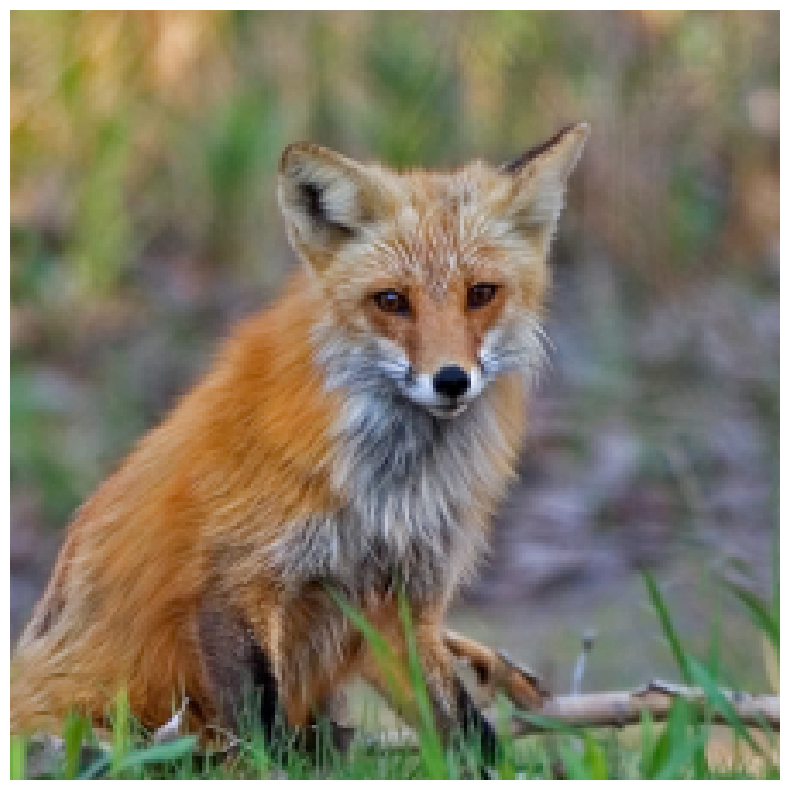

In [8]:
trans_img = img_input[0].detach().cpu().numpy()
trans_img = trans_img * std + mean
trans_img = trans_img.transpose(1, 2, 0)
trans_img = trans_img * 255
trans_img = trans_img.astype(np.uint8)
ax, fig = plt.subplots(1, 1, figsize=(10, 10))
plt.imshow(trans_img)
fig.axis("off")
plt.show()

In [9]:
prediction = model(img_input).squeeze(0)
class_id = prediction.argmax().item()
score = prediction[class_id].item()
category_name = model.categories[class_id]
print(f"{category_name}: {score * 100:.4f}")

red fox: 86.3738


## Generate the Saliency Maps

In [10]:
bound_min = -2.1179039478302    
bound_max = 2.640000104904175

### Original Gradient

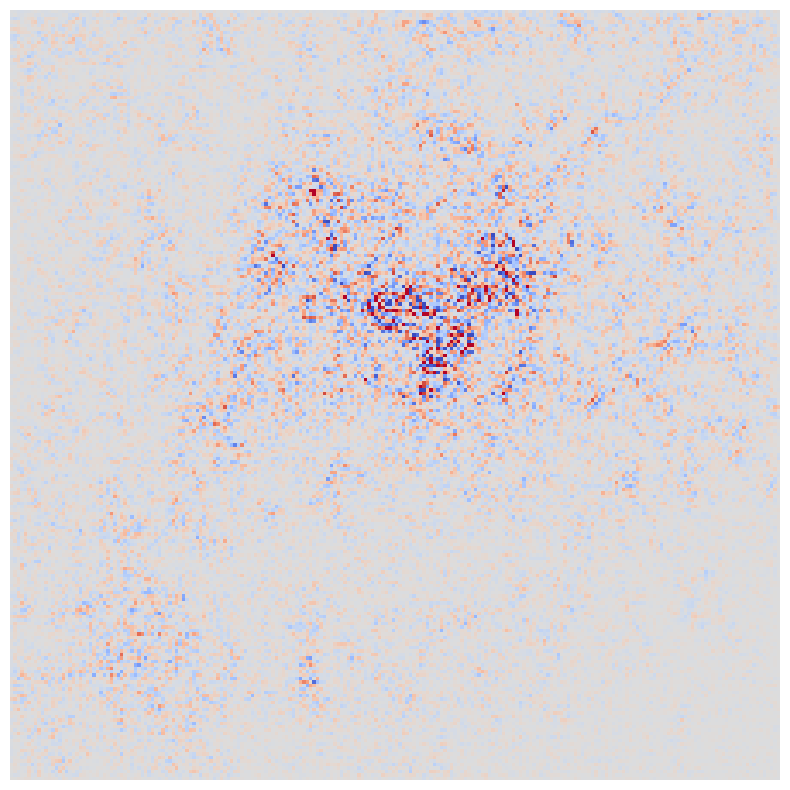

In [11]:
grad = VanillaGradient().cuda()
vanilla_salience = grad.gradient(model, img_input, class_id)
visual_imagenet(vanilla_salience)

### Setting for SmoothGrad and AdaptGrad

In [12]:
fixed_bound = FixedBound(lower=bound_min, upper=bound_max).cuda()
adapted_bound = AdaptedBound(lower=bound_min, upper=bound_max).cuda()
fixed_fixed_sigma = FixedSigma(alpha=0.2, bound=fixed_bound).cuda()
adapted_adapted_gaussian_sigma = AdaptedGaussianSigma(alpha=0.95, bound=adapted_bound).cuda()   # alpha is presented as t in this paper
smoothmask = GaussianMask(fixed_fixed_sigma).cuda()
adaptmask = GaussianMask(adapted_adapted_gaussian_sigma).cuda()

#### SmoothGrad

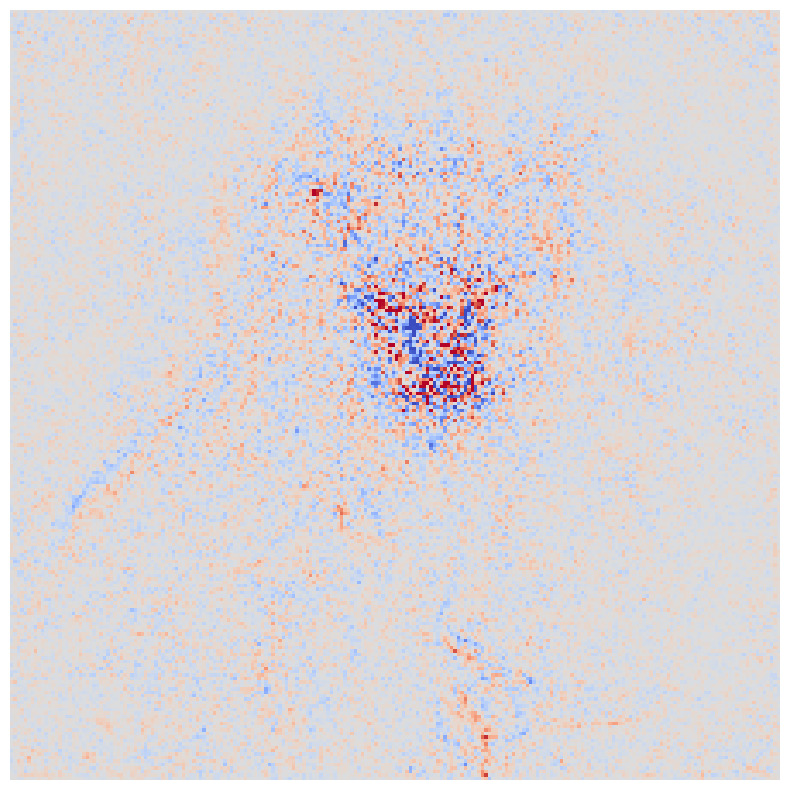

In [13]:
smoothgrad = SmoothGradient(mask=smoothmask, n_samples=50).cuda()
smooth_salience = smoothgrad.gradient(model, img_input, class_id)
visual_imagenet(smooth_salience)

#### AdaptGrad

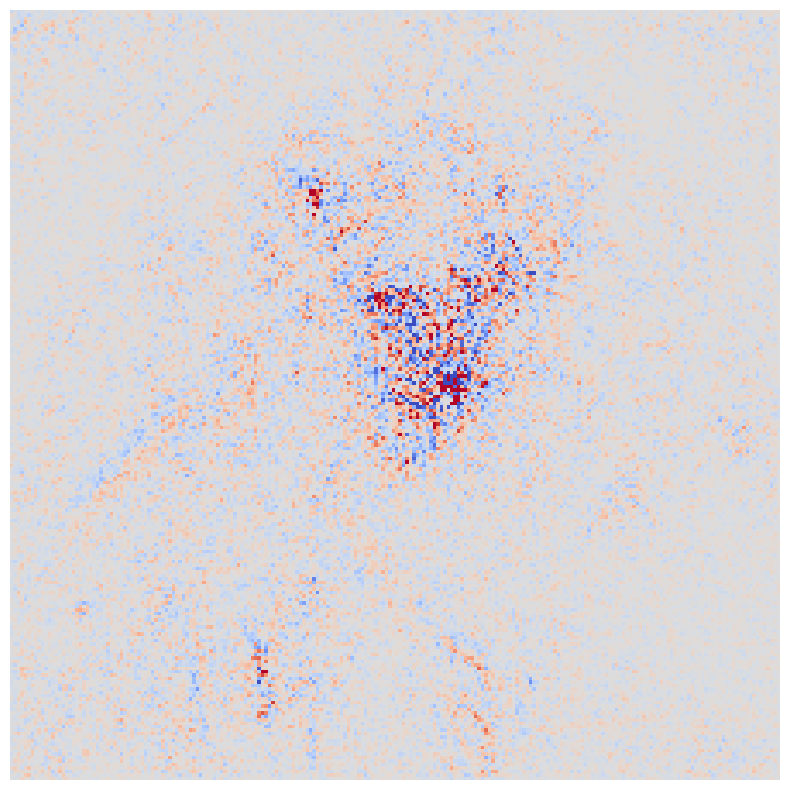

In [14]:
adaptgrad = SmoothGradient(mask=adaptmask, n_samples=50).cuda()
adapt_salience = adaptgrad.gradient(model, img_input, class_id)
visual_imagenet(adapt_salience)

#### GradientxInput

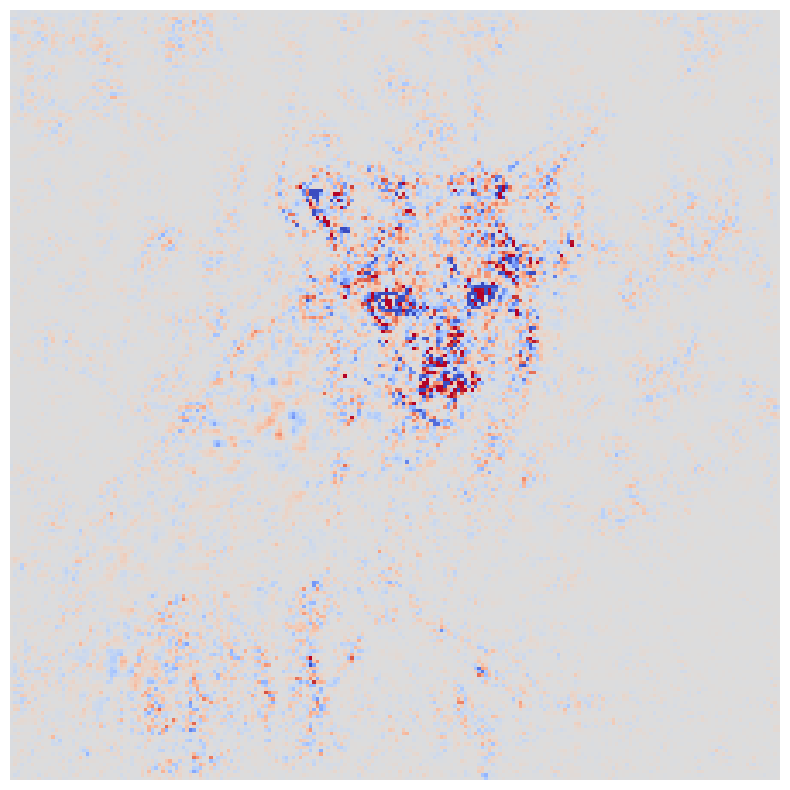

In [15]:
gi = GradientxInput(backgrad=grad).cuda()
gi_salience = gi.gradient(model, img_input, class_id)
visual_imagenet(gi_salience)

#### GradientxInput combined with SmoothGrad

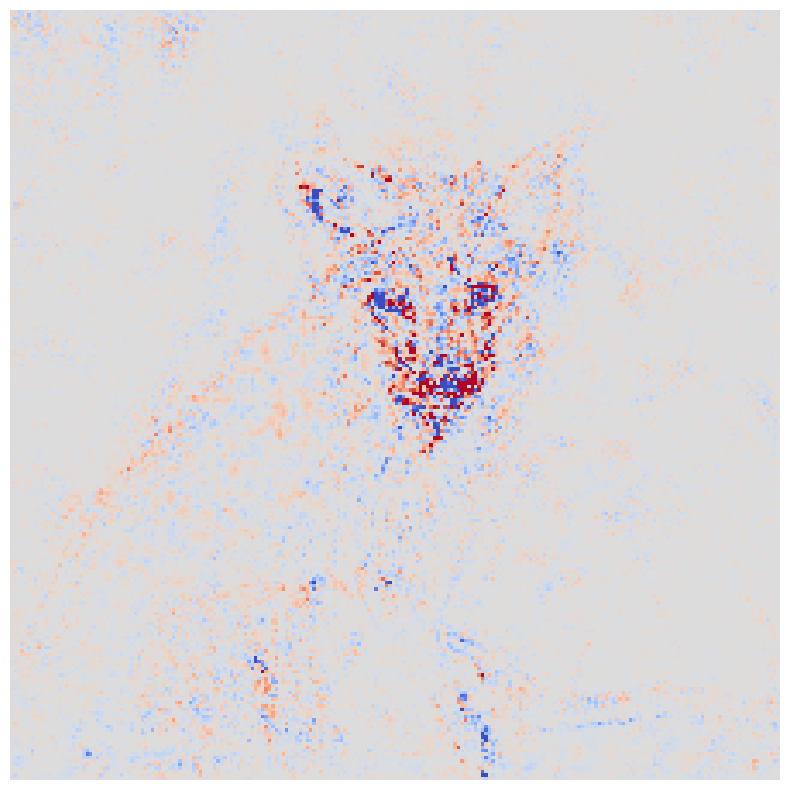

In [16]:
sgi = GradientxInput(backgrad=smoothgrad).cuda()
sgi_salience = sgi.gradient(model, img_input, class_id)
visual_imagenet(sgi_salience)

#### GradientxInput combined with AdaptGrad

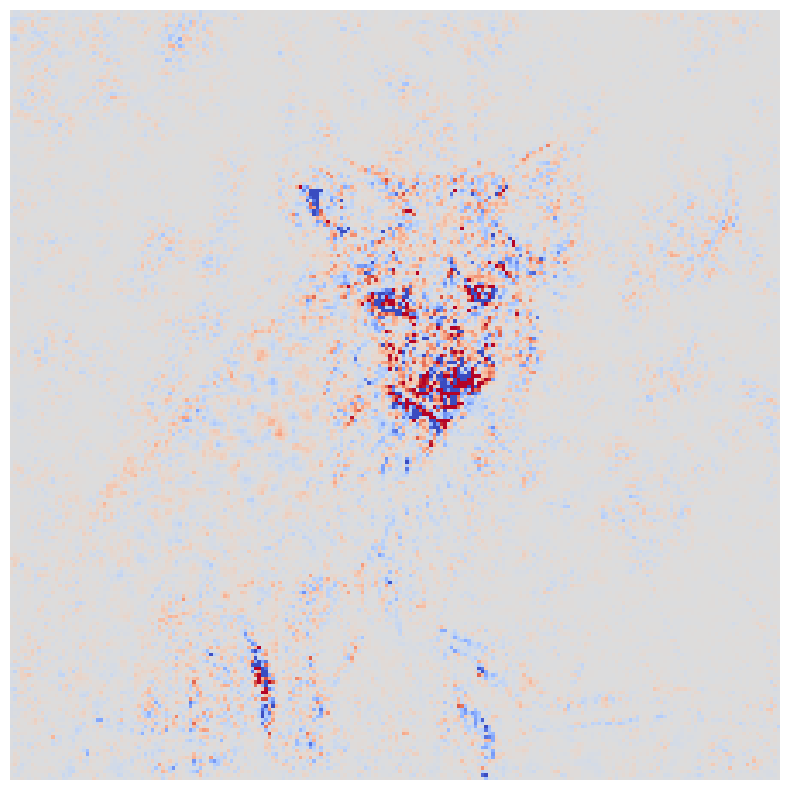

In [17]:
agi = GradientxInput(backgrad=adaptgrad).cuda()
agi_salience = agi.gradient(model, img_input, class_id)
visual_imagenet(agi_salience)

#### Integrated Gradient settings

In [18]:
white_baseline = WhiteBaseline().cuda()
black_baseline = BlackBaseline().cuda()

#### Integrated Gradient (white)

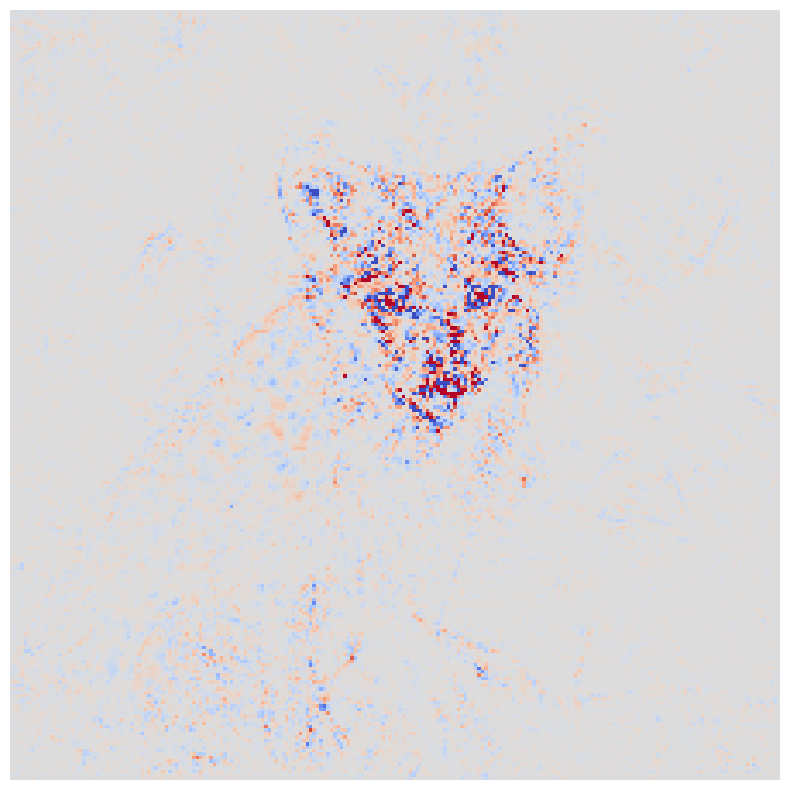

In [19]:
ig = IntegratedGradient(baseline=white_baseline,backgrad=grad,n_steps=50).cuda()
ig_salience = ig.gradient(model, img_input, class_id)
visual_imagenet(ig_salience)

#### Integrated Gradient (white) combined with SmoothGrad

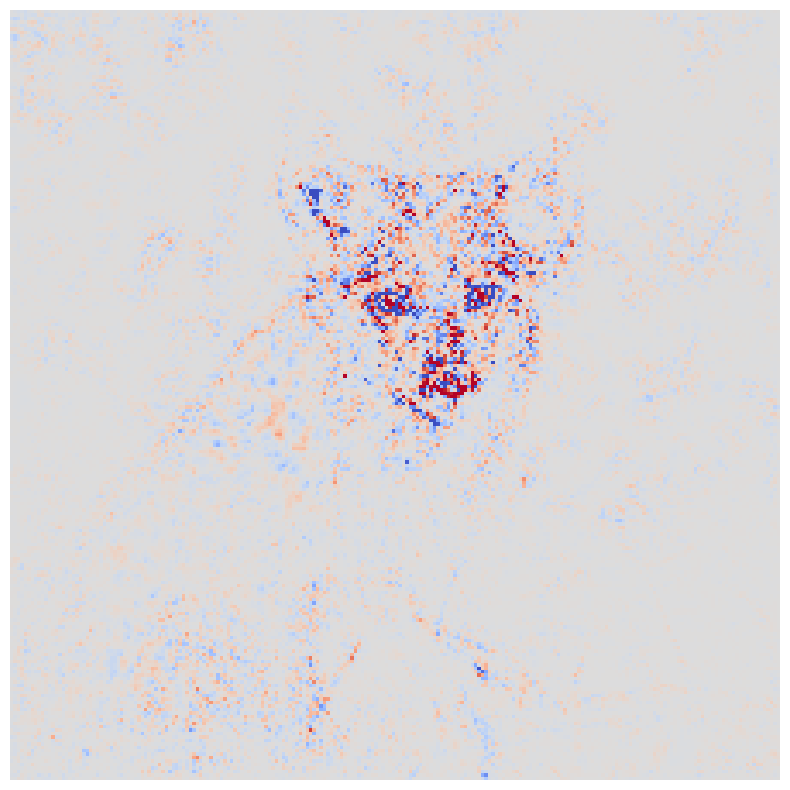

In [20]:
sig = IntegratedGradient(baseline=white_baseline,backgrad=smoothgrad,n_steps=50).cuda()
sig_salience = sig.gradient(model, img_input, class_id)
visual_imagenet(sig_salience)

#### Integrated Gradient (white) combined with AdaptGrad

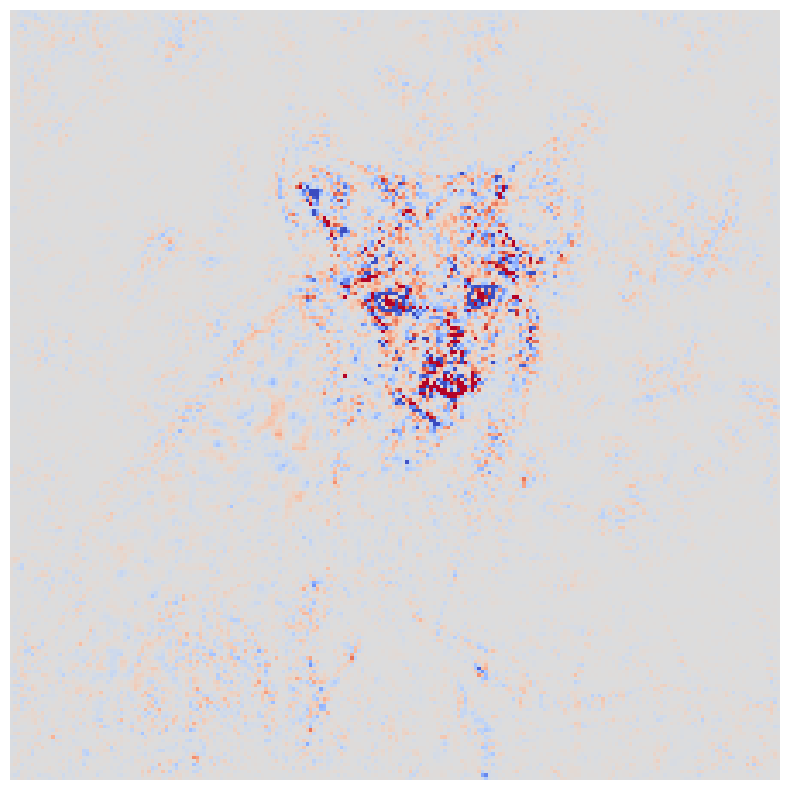

In [21]:
aigw = IntegratedGradient(baseline=white_baseline,backgrad=adaptgrad,n_steps=50).cuda()
aigw_salience = aigw.gradient(model, img_input, class_id)
visual_imagenet(aigw_salience)

#### Integrated Gradient (black)

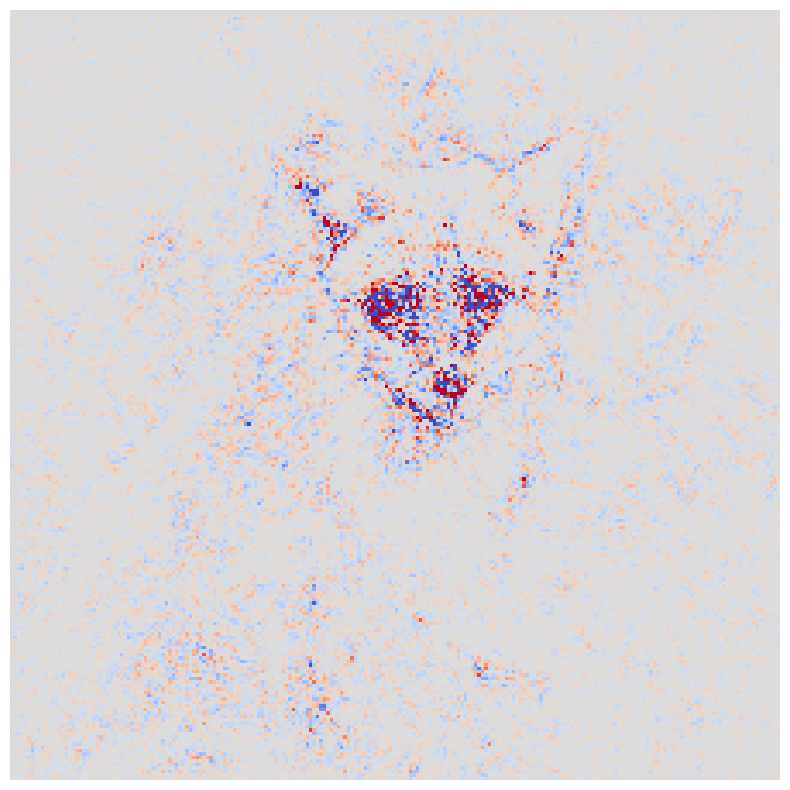

In [22]:
igb = IntegratedGradient(baseline=black_baseline,backgrad=grad,n_steps=50).cuda()
igb_salience = igb.gradient(model, img_input, class_id)
visual_imagenet(igb_salience)

#### Integrated Gradient (black) combined with SmoothGrad

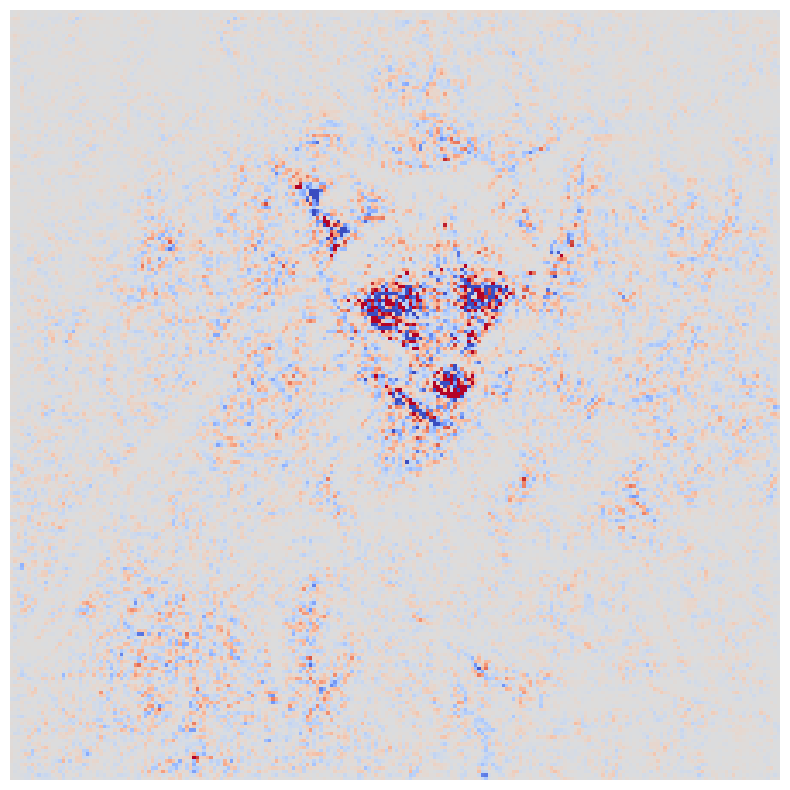

In [23]:
sigb = IntegratedGradient(baseline=black_baseline,backgrad=smoothgrad,n_steps=50).cuda()
sigb_salience = sigb.gradient(model, img_input, class_id)
visual_imagenet(sigb_salience)

#### Integrated Gradient (black) combined with AdaptGrad

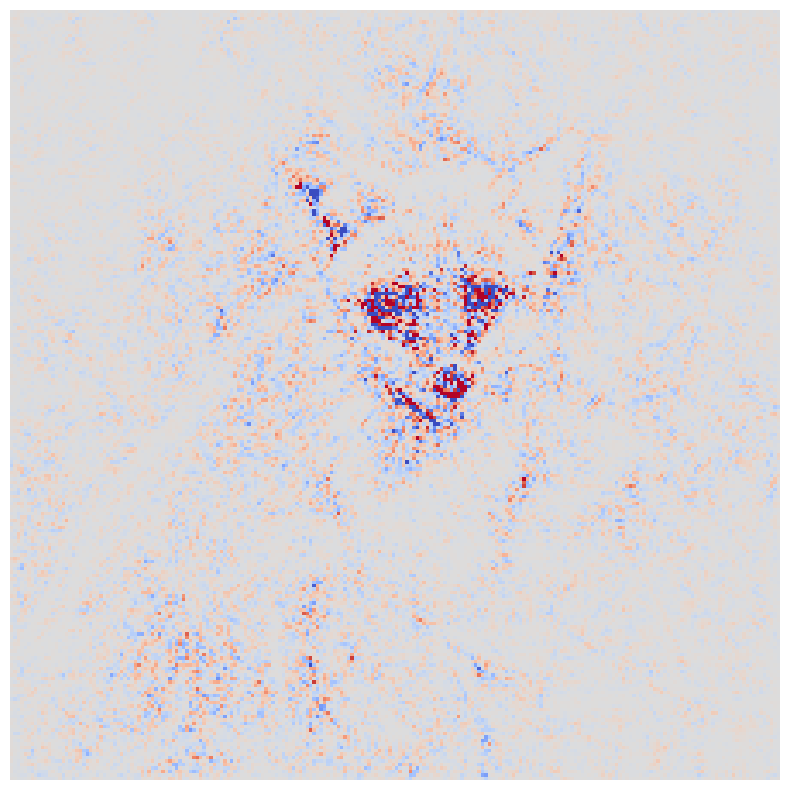

In [24]:
aigb = IntegratedGradient(baseline=black_baseline,backgrad=adaptgrad,n_steps=50).cuda()
aigb_salience = aigb.gradient(model, img_input, class_id)
visual_imagenet(aigb_salience)

#### NoiseGrad

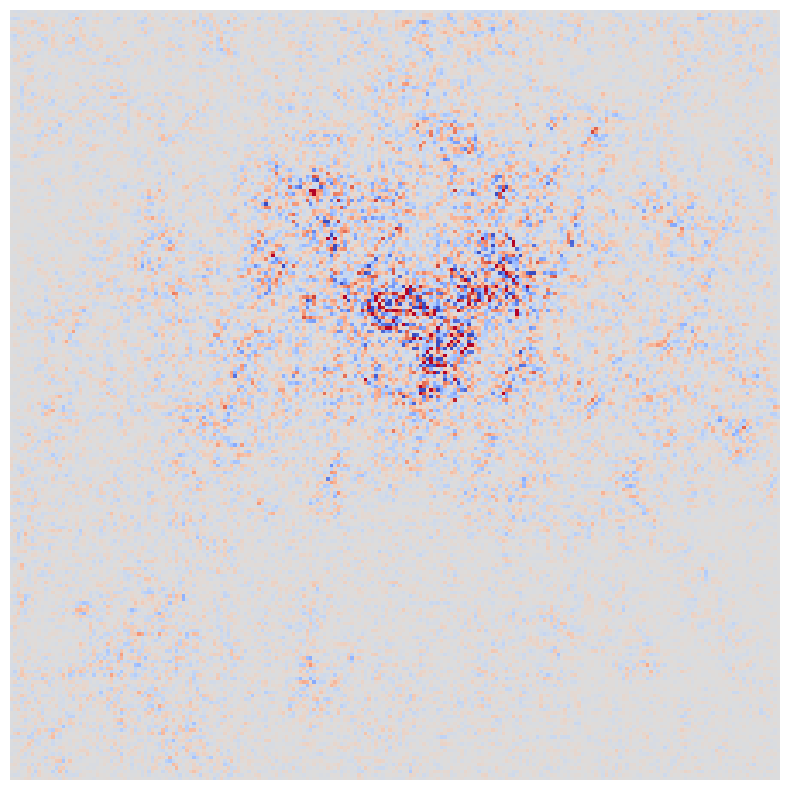

In [25]:
noise_bound = FixedBound(0, 1).cuda()
noise_sigma = FixedSigma(0.2, noise_bound).cuda()
noise_mask = GaussianMask(noise_sigma).cuda()
noisegrad = NoiseGradient(noise=noise_mask, n_samples=50, backgrad=grad).cuda()
noise_salience = noisegrad.gradient(model, img_input, class_id)
visual_imagenet(noise_salience)

#### NoiseGrad combined with SmoothGrad

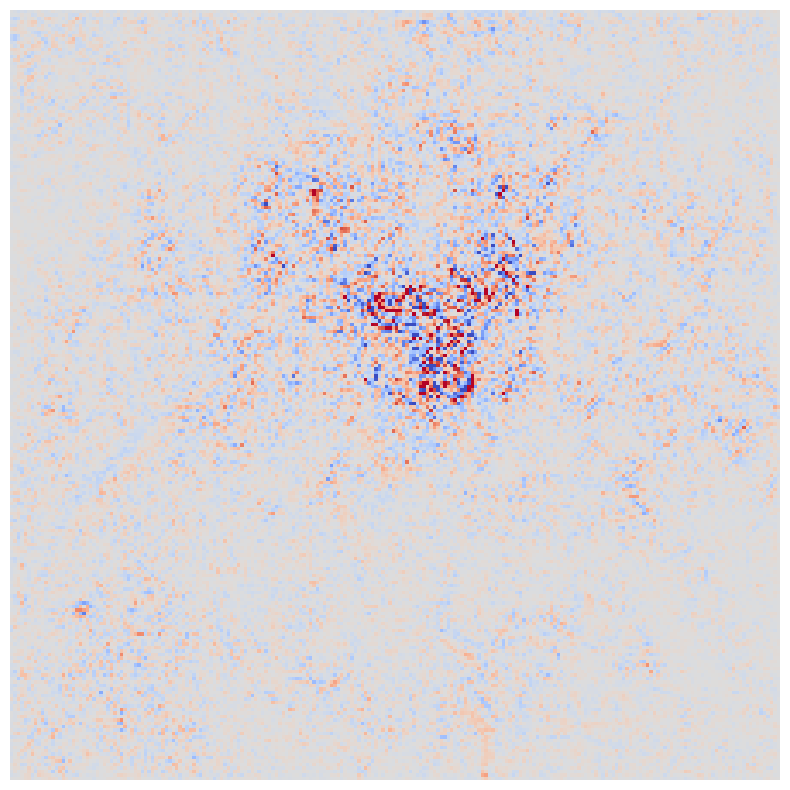

In [26]:
noisegrad = NoiseGradient(noise=noise_mask, n_samples=50, backgrad=smoothgrad).cuda()
noise_salience = noisegrad.gradient(model, img_input, class_id)
visual_imagenet(noise_salience)

#### NoiseGrad combined with AdaptGrad

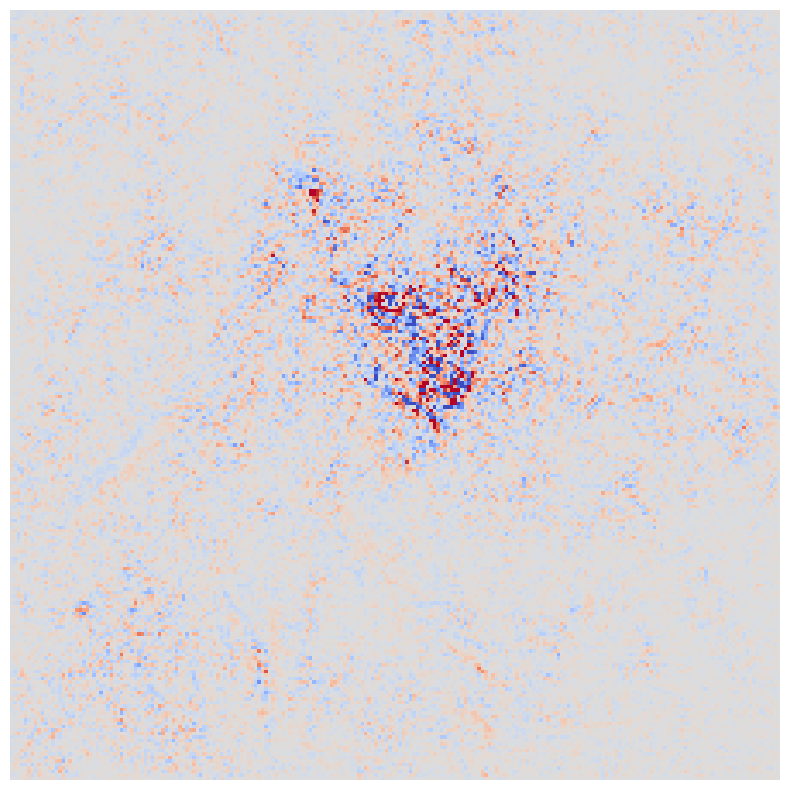

In [27]:
noisegrad = NoiseGradient(noise=noise_mask, n_samples=50, backgrad=adaptgrad).cuda()
noise_salience = noisegrad.gradient(model, img_input, class_id)
visual_imagenet(noise_salience)